# Проект. Исследование стартапов

## Введение

Контекст: Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных. Поработаем с информацией о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

Цель - подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.

<a id="contents"></a>
## Оглавление

1. [Введение](#Введение)

2. [Шаг 1. Знакомство с данными: загрузка и предобработка](#Шаг-1.-Знакомство-с-данными:-загрузка-и-предобработка)
3. [Шаг 2. Инжиниринг признаков](#Шаг-2.-Инжиниринг-признаков)
4. [Шаг 3. Работа с выбросами и анализ](#Шаг-3.-Работа-с-выбросами-и-анализ)
5. [Шаг 4. Анализ динамики](#Шаг-4.-Анализ-динамики)
6. [Шаг 5. Итоговый вывод и рекомендации](#Шаг-5.-Итоговый-вывод-и-рекомендации)

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации

In [1]:
!pip install phik

     |████████████████████████████████| 677 kB 2.2 MB/s eta 0:00:01


In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

In [3]:
cb_investments_df = pd.read_csv("data_cb_investments.zip", sep=';', low_memory=False)
cb_returns_df = pd.read_csv('data_cb_returns.csv')

Выводим информацию, которая необходима для принятия решений о предобработке

In [4]:
cb_investments_df.head(10)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,"1,20,00,000",operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Duke University,http://www.duke.edu,|Education|,Education,"87,00,000",operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,NaN,NaN,"60,00,000",operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,WeGame,http://www.WeGame.com,|Social Media|,Social Media,"35,00,000",acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
cb_investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `cb_investments_df` содержит 40 столбцов и 54294 строк, в которых представлена информация о компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:
- Все представленные данные хранятся в типах данных `object` и `float64`. `funding_total_usd` можно привести к типу float64.
- Пропуски содержатся во всех столбцах.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [6]:
cb_returns_df.head(15)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [7]:
cb_returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `cb_returns_df` содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

После первичного анализа данных можно сделать следующие выводы:
- Все представленные данные хранятся в типах данных `int64` и `float64`. `year` можно понизить разрядность до `int16`. У всех остальных столбцов можно понизить разрядность до `float32`.
- Пропусков нет.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

### 1.2. Предобработка данных

Проверим названия столбцов в датасетах, все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. Также займёмся оптимизацией типа данных

In [8]:
cb_returns_df['year'] = pd.to_numeric(cb_returns_df['year'], downcast='integer') 

for column in ['seed','venture','equity_crowdfunding','undisclosed', 'convertible_note', 'debt_financing',
              'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']:
    cb_returns_df[column] = pd.to_numeric(cb_returns_df[column], downcast='float')
    
print(cb_returns_df.dtypes)

year                      int16
seed                    float32
venture                 float32
equity_crowdfunding     float32
undisclosed             float32
convertible_note        float32
debt_financing          float32
angel                   float32
grant                   float32
private_equity          float32
post_ipo_equity         float32
post_ipo_debt           float32
secondary_market        float32
product_crowdfunding    float32
dtype: object


In [9]:
for column in ['funding_rounds','participants','founded_year','seed', 'venture', 'equity_crowdfunding',
              'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
              'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D',
              'round_E', 'round_F', 'round_G', 'round_H']:
    cb_investments_df[column] = pd.to_numeric(cb_investments_df[column], downcast='float')
    
print(cb_investments_df.dtypes)

name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float32
participants            float32
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float32
first_funding_at         object
mid_funding_at           object
last_funding_at          object
seed                    float32
venture                 float32
equity_crowdfunding     float32
undisclosed             float32
convertible_note        float32
debt_financing          float32
angel                   float32
grant                   float32
private_equity          float32
post_ipo_equity         float32
post_ipo_debt           float32
secondary_market        float32
product_

In [10]:
def to_snake_case(column_name):
    """
    Преобразует все столбцы в snake_case 
    """
    import re
    name = str(column_name).strip()
    name = re.sub(r'[\s-]+', '_', name)
    name = re.sub(r'(?<=[a-z])([A-Z])', r'_\1', name)
    name = name.lower()
    name = re.sub(r'_+', '_', name)
    name = name.strip('_')
    
    return name

cb_investments_df.columns = [to_snake_case(col) for col in cb_investments_df.columns]
cb_returns_df.columns = [to_snake_case(col) for col in cb_returns_df.columns]

Уберём в столбце `funding_total_usd` выделение разрядов и приведём его к числовому типу

In [11]:
cb_investments_df['funding_total_usd'] = cb_investments_df['funding_total_usd'].str.replace(',', '') 
cb_investments_df['funding_total_usd'] = pd.to_numeric(cb_investments_df['funding_total_usd'], errors='coerce')

for column in ['funding_total_usd']:
    cb_investments_df[column] = pd.to_numeric(cb_investments_df[column], downcast='float')
    
print(cb_investments_df.dtypes)

name                     object
homepage_url             object
category_list            object
market                   object
funding_total_usd       float32
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float32
participants            float32
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float32
first_funding_at         object
mid_funding_at           object
last_funding_at          object
seed                    float32
venture                 float32
equity_crowdfunding     float32
undisclosed             float32
convertible_note        float32
debt_financing          float32
angel                   float32
grant                   float32
private_equity          float32
post_ipo_equity         float32
post_ipo_debt           float32
secondary_market        float32
product_

In [12]:
print(cb_investments_df.head(5))

                              name           homepage_url  \
0               Harvard University     http://harvard.edu   
1      University of New Brunswick      http://www.unb.ca   
2                           DuPont  http://www.dupont.com   
3           University of Michigan  http://www.umich.edu/   
4  Case Western Reserve University    http://www.case.edu   

                                       category_list               market  \
0                                        |Education|           Education    
1                                                NaN                  NaN   
2  |Business Services|Agriculture|Automotive|Inve...   Business Services    
3                                        |Education|           Education    
4                                        |Education|           Education    

   funding_total_usd     status country_code state_code                region  \
0         90000000.0  operating          USA         MA                Boston   
1       

Обработаем типы данных в столбцах, которые хранят значения даты и времени

In [13]:
print(cb_investments_df[['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 
                        'mid_funding_at', 'last_funding_at']].dtypes)

founded_at           object
founded_month        object
founded_quarter      object
founded_year        float32
first_funding_at     object
mid_funding_at       object
last_funding_at      object
dtype: object


In [14]:
print(cb_investments_df[['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 
                        'mid_funding_at', 'last_funding_at']].head(5))

   founded_at founded_month founded_quarter  founded_year first_funding_at  \
0  1636-09-08           NaN             NaN        1636.0       2014-01-06   
1  1785-01-01           NaN             NaN        1785.0       2014-05-15   
2  1802-07-19           NaN             NaN        1802.0       2009-07-02   
3  1817-01-01           NaN             NaN        1817.0       2013-11-21   
4  1826-01-01           NaN             NaN        1826.0       2014-01-14   

  mid_funding_at last_funding_at  
0            NaN      2014-01-06  
1            NaN      2014-05-15  
2     2009-07-02      2009-07-02  
3     2013-11-21      2014-11-03  
4            NaN      2014-01-14  


In [15]:
cb_investments_df['founded_at'] = pd.to_datetime(cb_investments_df['founded_at'], errors='coerce')
cb_investments_df['first_funding_at'] = pd.to_datetime(cb_investments_df['first_funding_at'], errors='coerce')
cb_investments_df['mid_funding_at'] = pd.to_datetime(cb_investments_df['mid_funding_at'], errors='coerce')
cb_investments_df['last_funding_at'] = pd.to_datetime(cb_investments_df['last_funding_at'], errors='coerce')
cb_investments_df['founded_month'] = pd.to_datetime(cb_investments_df['founded_month'], format='%Y-%m', errors='coerce')

print(cb_investments_df[['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 
                        'mid_funding_at', 'last_funding_at']].dtypes)

founded_at          datetime64[ns]
founded_month       datetime64[ns]
founded_quarter             object
founded_year               float32
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object


В датасете `cb_returns` сделае  столбец `year` индексом всего датасета

In [16]:
cb_returns_df.set_index('year', inplace=True)

cb_returns_df.head(5)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.700001,55.400002,0.0,78.209999,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.880000,23.490000,0.0,21.500000,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.590000,209.419998,0.0,25.770000,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.740000,233.860001,0.0,9.400000,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.930000,555.900024,0.0,33.189999,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Обработаем текстовые данные. Пропуски в текстовых столбцах заменим заглушками

In [17]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"

    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(cb_investments_df)

,Кол-во пропусков,Доля пропусков
name,4857,0.0895
homepage_url,8305,0.1530
category_list,8817,0.1624
market,8817,0.1624
funding_total_usd,13387,0.2466
status,6170,0.1136
country_code,10129,0.1866
state_code,24133,0.4445
region,10129,0.1866
city,10972,0.2021


Мы имеем следующие текстовые столбцы: `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code`, `region`, `city`. Было принято решение оставить пропуски во всех текстовых столбцах. Когда пропуски можно оставить не заполненными:
- если пропуски составляют значительный процент (например, более 30–40%) и заполнить их корректно затруднительно; 
- если последующий анализ предусматривает фильтрацию или агрегацию данных, пропуски могут быть просто исключены из анализа без последствий.

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Удалим те строки, которые не несут какой-либо информации либо не содержат данных о финансировании

In [18]:
cb_investments_df.duplicated().sum()

4855

Обнаружено 4855 полных дубликатов, удалим их.

In [19]:
cb_investments_df = cb_investments_df.drop_duplicates()

In [20]:
pass_funding_total_usd = cb_investments_df[cb_investments_df['funding_total_usd'].isna()]
print(f"Строк с пропусками в funding_total_usd: {len(pass_funding_total_usd)}")

print(pass_funding_total_usd[['seed', 'venture', 'equity_crowdfunding', 'debt_financing', 'secondary_market', 'angel',
                              'undisclosed', 'grant', 'private_equity', 'post_ipo_equity', 'convertible_note',
                              'post_ipo_debt', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d',
                              'round_e', 'round_f', 'round_g', 'round_h']].head(10))

Строк с пропусками в funding_total_usd: 8532
     seed  venture  equity_crowdfunding  debt_financing  secondary_market  \
13    0.0      0.0                  0.0             0.0               0.0   
15    0.0      0.0                  0.0             0.0               0.0   
19    0.0      0.0                  0.0             0.0               0.0   
27    0.0      0.0                  0.0             0.0               0.0   
35    0.0      0.0                  0.0             0.0               0.0   
59    0.0      0.0                  0.0             0.0               0.0   
84    0.0      0.0                  0.0             0.0               0.0   
105   0.0      0.0                  0.0             0.0               0.0   
124   0.0      0.0                  0.0             0.0               0.0   
135   0.0      0.0                  0.0             0.0               0.0   

     angel  undisclosed  grant  private_equity  post_ipo_equity  ...  \
13     0.0          0.0    0.0     

Видим, что строки с пропусками в столбце `funding_total_usd` не содержат никаких данных о финансировании. Удалим эти строки.

In [21]:
cb_investments_df = cb_investments_df.dropna(subset=['funding_total_usd'])

pass_funding_total_usd = cb_investments_df[cb_investments_df['funding_total_usd'].isna()]
print(f"Строк с пропусками в funding_total_usd: {len(pass_funding_total_usd)}")

print(pass_funding_total_usd[['seed', 'venture', 'equity_crowdfunding', 'debt_financing', 'secondary_market', 'angel',
                              'undisclosed', 'grant', 'private_equity', 'post_ipo_equity', 'convertible_note',
                              'post_ipo_debt', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d',
                              'round_e', 'round_f', 'round_g', 'round_h']].head(10))

Строк с пропусками в funding_total_usd: 0
Empty DataFrame
Columns: [seed, venture, equity_crowdfunding, debt_financing, secondary_market, angel, undisclosed, grant, private_equity, post_ipo_equity, convertible_note, post_ipo_debt, product_crowdfunding, round_a, round_b, round_c, round_d, round_e, round_f, round_g, round_h]
Index: []

[0 rows x 21 columns]


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами. Оценим размер оставшихся пропусков в столбце

In [22]:
pass_mid_funding_at = cb_investments_df[cb_investments_df['mid_funding_at'].isna()].copy()

pass_mid_funding_at['mid_funding_at'] = pass_mid_funding_at['first_funding_at']+(pass_mid_funding_at[
                                        'last_funding_at']-pass_mid_funding_at['first_funding_at']) / 2

cb_investments_df.update(pass_mid_funding_at)

print(cb_investments_df['mid_funding_at'].isna().sum())

1


In [23]:
pass_1 = cb_investments_df[cb_investments_df['mid_funding_at'].isna()]
print(pass_1[['name', 'first_funding_at', 'last_funding_at', 'mid_funding_at']])

         name first_funding_at last_funding_at mid_funding_at
33041  Nubank              NaT      2014-09-25            NaT


Остался 1 пропуск по причине отсутствия возможности вычислить его значение, поскольку значения `first_funding_at` для его вычисления не существует.

Оценим полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта

В датасете `cb_investments_df` изначально было 54294 строки, 40 столбцов.
В датасете `cb_returns_df` изначально было 15 строк, 14 столбцов.

Текущее кол-во строк и столбцов обоих датасетов:

In [24]:
print(cb_investments_df.shape) 
print(cb_returns_df.shape)

(40907, 40)
(15, 13)


В датасете `cb_returns_df` без особых изменений (столбец `year` стал индексом), в отличие от датасета `cb_investments_df`.

Выведем информацию об отброшенных данных:

In [25]:
count_delete = 54294-40907
print(f'Кол-во строк отброшено в датасете cb_investments_df:{count_delete}')
print(f'Доля строк, отброшеных в датасете cb_investments_df:{round((count_delete/54294)*100, 2)}%')

Кол-во строк отброшено в датасете cb_investments_df:13387
Доля строк, отброшеных в датасете cb_investments_df:24.66%


Данных для решения задач проекта достаточно:
- сохранены ключевые признаки;
- потери данных оправданы (удалили строки, не содержащие данные о финансировании, полные дубликаты).

## Шаг 2. Инжиниринг признаков

[↑ К оглавлению](#contents)

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [26]:
cb_investments_df['difference_finance'] = (cb_investments_df['last_funding_at'] - cb_investments_df['first_funding_at']).dt.days

cb_investments_df_fr1 = cb_investments_df[cb_investments_df['funding_rounds'] == 1.0]

cb_investments_df_1year = cb_investments_df[(cb_investments_df['difference_finance'] <= 365) & 
                                            (cb_investments_df['funding_rounds'] > 1.0)]

cb_investments_df_1year_more = cb_investments_df[(cb_investments_df['difference_finance'] > 365) & 
                                                 (cb_investments_df['funding_rounds'] > 1.0)]

print(cb_investments_df_fr1['funding_rounds'].head(5))
print(cb_investments_df_1year['difference_finance'].head(5))
print(cb_investments_df_1year_more['difference_finance'].head(5))

print(len(cb_investments_df_fr1))
print(len(cb_investments_df_1year))
print(len(cb_investments_df_1year_more))

0    1.0
1    1.0
2    1.0
4    1.0
5    1.0
Name: funding_rounds, dtype: float32
3     347.0
6     108.0
9     152.0
17    142.0
37      0.0
Name: difference_finance, dtype: float64
25    2508.0
29     961.0
30     601.0
62     644.0
63     991.0
Name: difference_finance, dtype: float64
24113
4501
12291


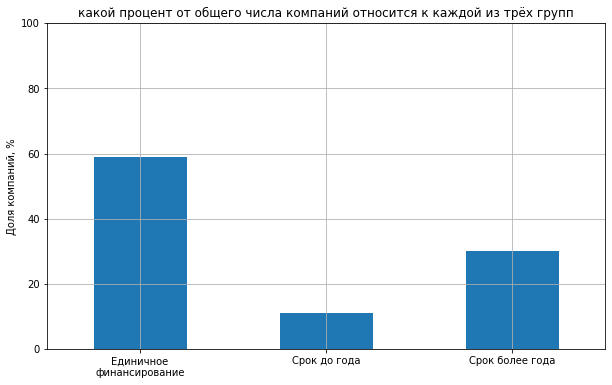

In [27]:
plt.figure(figsize=(10, 6))

company_groups = pd.Series(
    [len(cb_investments_df_fr1), len(cb_investments_df_1year), len(cb_investments_df_1year_more)],
    index=['Единичное\nфинансирование', 'Срок до года', 'Срок более года']
)

total_companies = len(cb_investments_df)

(company_groups / total_companies * 100).plot(
    kind='bar',
    rot=0,
    title=f'какой процент от общего числа компаний относится к каждой из трёх групп'
)

plt.ylabel('Доля компаний, %')
plt.ylim(0, 100)
plt.grid()

plt.show()

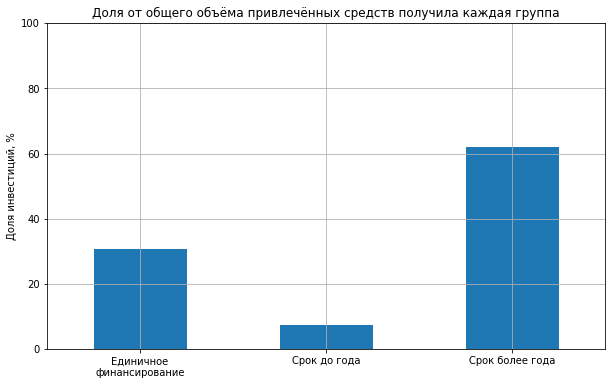

In [28]:
plt.figure(figsize=(10, 6))

investment_dist = pd.Series(
        [cb_investments_df_fr1['funding_total_usd'].sum(), 
     cb_investments_df_1year['funding_total_usd'].sum(),
     cb_investments_df_1year_more['funding_total_usd'].sum()],
    index=['Единичное\nфинансирование', 'Срок до года', 'Срок более года']
)

total_investment = cb_investments_df['funding_total_usd'].sum()

(investment_dist / total_investment * 100).plot(
    kind='bar',
    rot=0,
    title='Доля от общего объёма привлечённых средств получила каждая группа',
)

plt.ylabel('Доля инвестиций, %')
plt.ylim(0, 100)
plt.grid()

plt.show()

Промежуточный вывод:

- Компании с долгим сроком финансирования (более года) составляют всего 30% от всех компаний, но привлекают более 60% всех инвестиций — средний чек на такую компанию в 2 раза выше, чем в других сегментах.

- Рекомендации для заказчика:
Если цель — максимальный объём инвестиций при ограниченном числе сделок, стоит фокусироваться на компаниях с долгим сроком финансирования. Они требуют больше времени на сопровождение, но приносят основной объём капитала.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесём к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесём к средним, а сегменты до 35 компаний отнесём к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построем график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [29]:
market_count = cb_investments_df['market'].value_counts()
market_count

 Software          4190
 Biotechnology     3531
 Mobile            1852
 E-Commerce        1528
 Curated Web       1404
                   ... 
iPhone                1
 Defense              1
 Consumer Goods       1
 Swimming             1
 Shoes                1
Name: market, Length: 848, dtype: int64

In [30]:
def classificases_market(count):
    """
    Функция классифицирует сегмент по количеству компаний
    """
    if count > 120:
        return 'Массовый'
    elif 35 <= count <= 120:
        return 'Средний'
    elif count < 35:
        return 'Нишевой'
 
market_types = market_count.apply(classificases_market)
market_types

 Software          Массовый
 Biotechnology     Массовый
 Mobile            Массовый
 E-Commerce        Массовый
 Curated Web       Массовый
                     ...   
iPhone              Нишевой
 Defense            Нишевой
 Consumer Goods     Нишевой
 Swimming           Нишевой
 Shoes              Нишевой
Name: market, Length: 848, dtype: object

In [31]:
segment_counts = market_types.value_counts()
print("\n Количество сегментов по категориям:")
print(segment_counts)
print("\n Доля сегментов по категориям:")
print(round(segment_counts / len(market_types) * 100, 1))


 Количество сегментов по категориям:
Нишевой     714
Средний      81
Массовый     53
Name: market, dtype: int64

 Доля сегментов по категориям:
Нишевой     84.2
Средний      9.6
Массовый     6.2
Name: market, dtype: float64


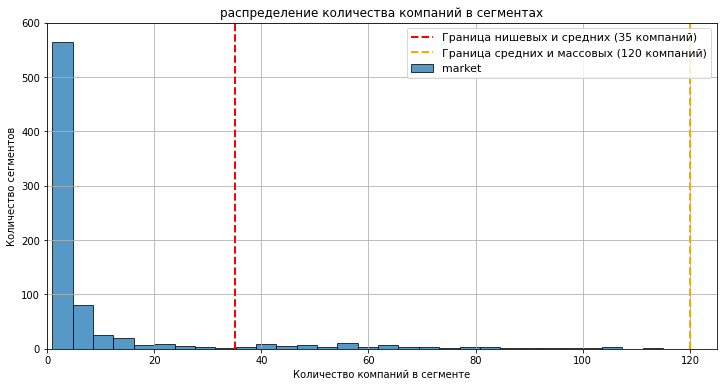

In [32]:
plt.figure(figsize=(12, 6))

only_niche_middle_values = market_count[market_count <= 120]

only_niche_middle_values.plot(
                kind='hist', 
                bins=30, 
                alpha=0.75,
                edgecolor='black',
                rot=0,
)
plt.axvline(x=35, color='red', linestyle='--', linewidth=2, 
            label='Граница нишевых и средних (35 компаний)')
plt.axvline(x=120, color='orange', linestyle='--', linewidth=2, 
            label='Граница средних и массовых (120 компаний)')

plt.legend(fontsize=11, loc='upper right')

plt.title('распределение количества компаний в сегментах')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.xlim(0 ,125)
plt.ylim(0 ,600)

plt.grid()

plt.show() 

Промежуточный вывод:
- Наблюдается эффект "длинного хвоста" — большое количество нишевых сегментов (84% от всех) содержат относительно мало компаний, в то время как небольшое количество массовых сегментов (всего 6%) аккумулируют основную массу компаний.
- Рекомендация для заказчика:
 - Если цель — широкий охват и диверсификация, стоит рассматривать нишевые сегменты
 - Если цель — максимальный объем инвестиций при ограниченном количестве сделок, 
  фокус должен быть на массовых сегментах.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования будем выполнять с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не будем — они объединяются в два общих сегмента.

In [33]:
cb_investments_df['market_groups'] = cb_investments_df['market'].copy()

for market_name, count in market_count.items():
    if count > 120:
        cb_investments_df.loc[cb_investments_df['market'] == market_name, 'market_groups'] = market_name
    elif 35 <= count <= 120:
        cb_investments_df.loc[cb_investments_df['market'] == market_name, 'market_groups'] = 'mid'
    else:  
        cb_investments_df.loc[cb_investments_df['market'] == market_name, 'market_groups'] = 'niche'

print(cb_investments_df['market_groups'].head(15))

0                Education 
1                       NaN
2                       mid
3                Education 
4                Education 
5                       NaN
6                Education 
7                Education 
8                       NaN
9             Social Media 
10     Hardware + Software 
11           Biotechnology 
12                    niche
14                      NaN
16               Education 
Name: market_groups, dtype: object


## Шаг 3. Работа с выбросами и анализ
[↑ К оглавлению](#contents)

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

In [34]:
cb_investments_df['funding_total_usd'].head(5)

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float32

In [35]:
cb_investments_df['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591252e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Статистические показатели столбца `funding_total_usd` выше показывают, что значения имеют огромный разброс, по этой причине графики ниже сильно ужаты до более ли менее популярных значений (при базовых границах значений столбца `funding_total_usd` графики ниже были бы не подходящими для восприятия).

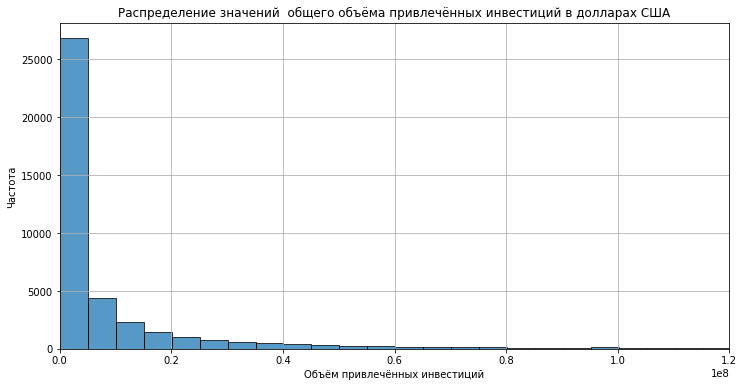

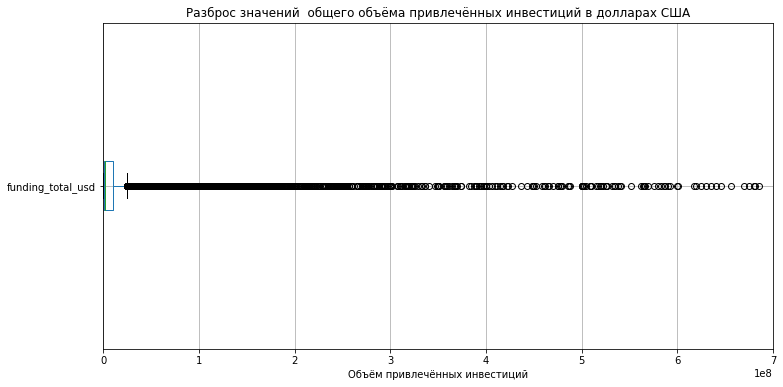

In [36]:
plt.figure(figsize=(12, 6))

cb_investments_df['funding_total_usd'].plot(
                kind='hist', 
                bins=6000, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

plt.title('Распределение значений  общего объёма привлечённых инвестиций в долларах США')
plt.xlabel('Объём привлечённых инвестиций')
plt.ylabel('Частота')
plt.xlim(0, 120000000)

plt.grid()

plt.show() 

plt.figure(figsize=(12, 6))

cb_investments_df.boxplot(column='funding_total_usd', vert=False)

plt.title('Разброс значений  общего объёма привлечённых инвестиций в долларах США')
plt.xlabel('Объём привлечённых инвестиций')
plt.xlim(0, 700000000)

plt.show() 

Предварительный вывод:
- Исходя из выше представленных данных можно сказать, что типичный интервал размера общего финансирования для одной компании равняется приблизительно от 350.000 до 10.000.000 долларов США, выбивающимся - от 10.000.000 до 30.000.000.000 долларов США, менее 350.000 долларов США (микро-инвестиции).

Определим компании с аномальным объёмом общего финансирования. Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [37]:
q1 = cb_investments_df['funding_total_usd'].quantile(0.25)
q3 = cb_investments_df['funding_total_usd'].quantile(0.75)

outliers_mask = (cb_investments_df['funding_total_usd'] <= q1) | (cb_investments_df['funding_total_usd'] >= q3)

outliers_df = cb_investments_df[outliers_mask]

print("Топ 10 компаний с аномальным объёмом общего финансирования")
print(outliers_df[['name', 'funding_total_usd']].head(10).sort_values(by='funding_total_usd', ascending=False))

Топ 10 компаний с аномальным объёмом общего финансирования
                                           name  funding_total_usd
17                       University of Maryland        750499968.0
20                 Great Atlantic & Pacific Tea        175000000.0
0                            Harvard University         90000000.0
23  Massachusetts Institute of Technology - MIT         90000000.0
25                                      Athenix         43500000.0
10                                    VideoSurf         28000000.0
5                             Xavier University         19000000.0
22                                 Watkins Hire         15304039.0
6                             Tulane University         12000000.0
24                         Saint Agnes Hospital           197634.0


In [38]:
cb_investments_df['is_outlier'] = outliers_mask

segment_outlier_rate = (
    cb_investments_df
    .groupby('market')['is_outlier']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'всего_компаний', 'mean': 'доля_выбросов'})
)

segment_outlier_rate = segment_outlier_rate.sort_values('доля_выбросов', ascending=False)

top_segments = segment_outlier_rate[segment_outlier_rate['всего_компаний'] >= 10].head(10)
print("Топ сегментов с наибольшей долей аномального финансирования:")
print(top_segments)

Топ сегментов с наибольшей долей аномального финансирования:
                     всего_компаний  доля_выбросов
market                                            
Search                           10       0.800000
Hardware + Software              16       0.750000
Health and Wellness              16       0.750000
 Real Time                       38       0.736842
 Logistics                       11       0.727273
 Wireless                        62       0.725806
Clean Technology                 24       0.708333
Web Hosting                      10       0.700000
Biotechnology                    20       0.700000
 Banking                         13       0.692308


Промежуточный вывод:
- Аномалии в финансировании сосредоточены в двух типах сегментов:
 - Научно-образовательные и исследовательские;
 - Научно-образовательные и исследовательские;
 - Технологические и инфраструктурные.
- Для заказчика это означает, что при выходе на рынок наиболее перспективными с точки зрения объёмов, но и наиболее рискованными (из-за высокой концентрации) являются именно технологические и научные сегменты. Инвестиции в них требуют тщательного отбора компаний, так как лишь малая доля из них получает основную массу финансирования.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Когда исключим аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

1921        1
1960        1
1979        1
1982        3
1983        1
1984        1
1985        3
1987        2
1989        1
1990        1
1992        3
1993        1
1994        5
1995        2
1996        1
1997        4
1998        8
1999       26
2000       63
2001       50
2002       47
2003       53
2004       86
2005      646
2006     1007
2007     1332
2008     1700
2009     2441
2010     3410
2011     4109
2012     5296
2013     8687
2014    11915
Name: last_funding_year, dtype: int64


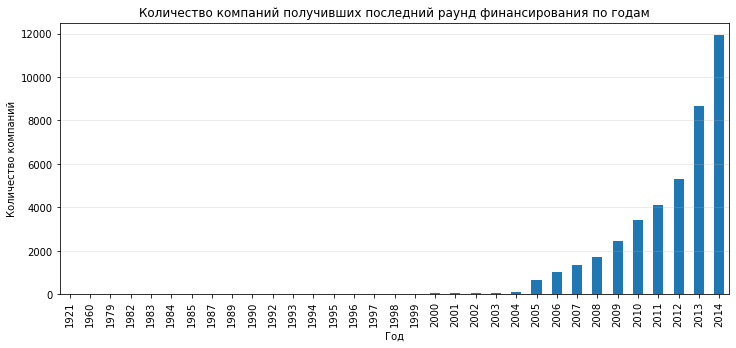

Компаний в 2014: 11915
Компаний в 2013: 8687


In [39]:
cb_investments_df['last_funding_year'] = pd.to_datetime(cb_investments_df['last_funding_at']).dt.year

funding_by_year = cb_investments_df['last_funding_year'].value_counts().sort_index()
print(funding_by_year)

plt.figure(figsize=(12, 5))
funding_by_year.plot(kind='bar')
plt.title('Количество компаний получивших последний раунд финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество компаний')
plt.grid(axis='y', alpha=0.3)
plt.show()

if 2014 in funding_by_year.index:
    count_2014 = funding_by_year[2014]
    count_2013 = funding_by_year.get(2013, 0) 
    print(f"Компаний в 2014: {count_2014}")
    print(f"Компаний в 2013: {count_2013}")

Исходя из выше представленной информации, данные за 2014 год можно считать полными и пригодными для анализа.

In [40]:
cb_investments_df = cb_investments_df[outliers_mask == False]

print(f"\nПосле удаления аномалий осталось компаний: {len(cb_investments_df)}")

print(f"выводим статистич.данные столбца funding_total_usd")
print(cb_investments_df['funding_total_usd'].describe())


После удаления аномалий осталось компаний: 20343
выводим статистич.данные столбца funding_total_usd
count      20343.00
mean     2879512.75
std      2436317.75
min       350001.00
25%      1000000.00
50%      2000000.00
75%      4300000.00
max      9999999.00
Name: funding_total_usd, dtype: float64


In [41]:
cb_investments_df['mid_funding_year'] = pd.to_datetime(cb_investments_df['mid_funding_at']).dt.year

yearly_activity = cb_investments_df['mid_funding_year'].value_counts().sort_index()

active_years = yearly_activity[yearly_activity >= 50].index.tolist()

if active_years:
    cb_investments_df = cb_investments_df[cb_investments_df['mid_funding_year'].isin(active_years)]

cb_investments_df = cb_investments_df.drop(columns=['mid_funding_year'])

print(f"Итоговое количество компаний после фильтрации: {len(cb_investments_df)}")

Итоговое количество компаний после фильтрации: 20176


### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

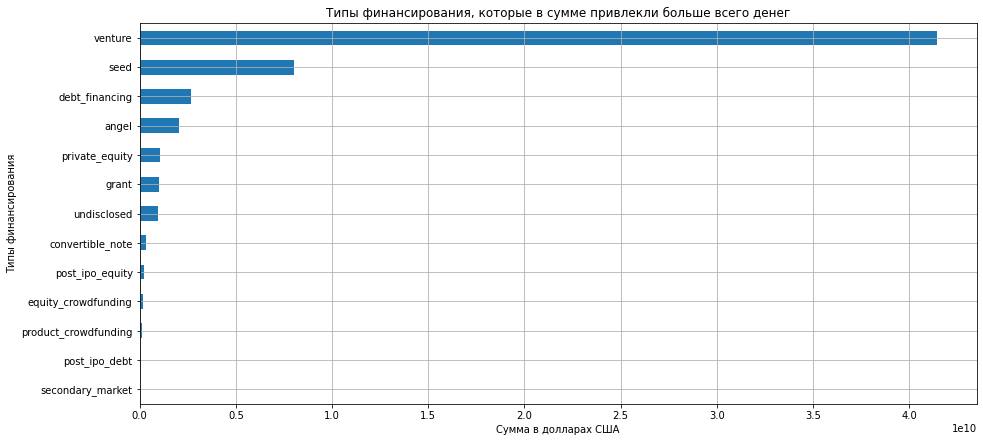

In [42]:
plt.figure(figsize=(15, 7))

cb_investments_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                   'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                   'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum().sort_values().plot(
                    kind='barh', 
                    rot=0, 
                    legend=False,
                    title=f'Типы финансирования, которые в сумме привлекли больше всего денег'
)

plt.xlabel('Сумма в долларах США')
plt.ylabel('Типы финансирования')  

plt.grid() 

plt.show() 

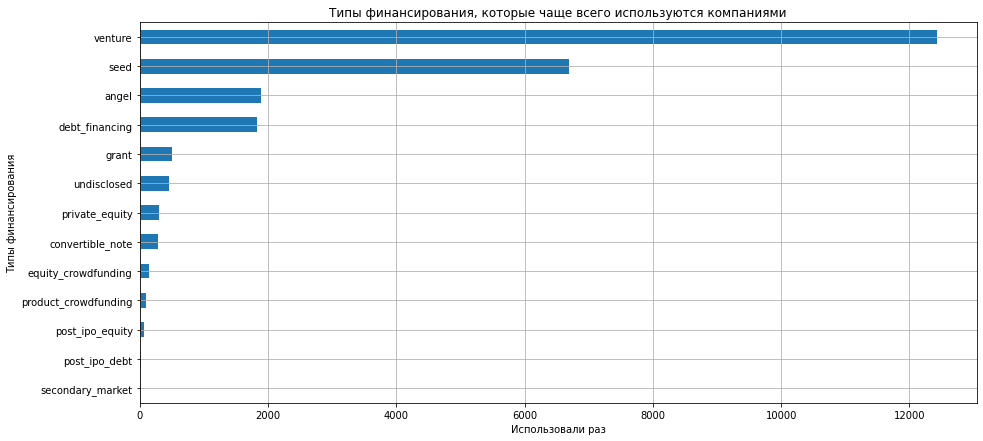

In [43]:
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

popularity = (cb_investments_df[funding_types] > 0).sum().sort_values()

plt.figure(figsize=(15, 7))

popularity.plot(
               kind='barh', 
               rot=0, 
               legend=False, 
               title=f'Типы финансирования, которые чаще всего используются компаниями'
)

plt.xlabel('Использовали раз')
plt.ylabel('Типы финансирования')  

plt.grid() 

plt.show() 

Самые часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами:
- angel;
- grant.

Самые редкие типы финансирования, которые при этом характеризуются значительным объёмом предоставленных сумм:
- private_equity.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

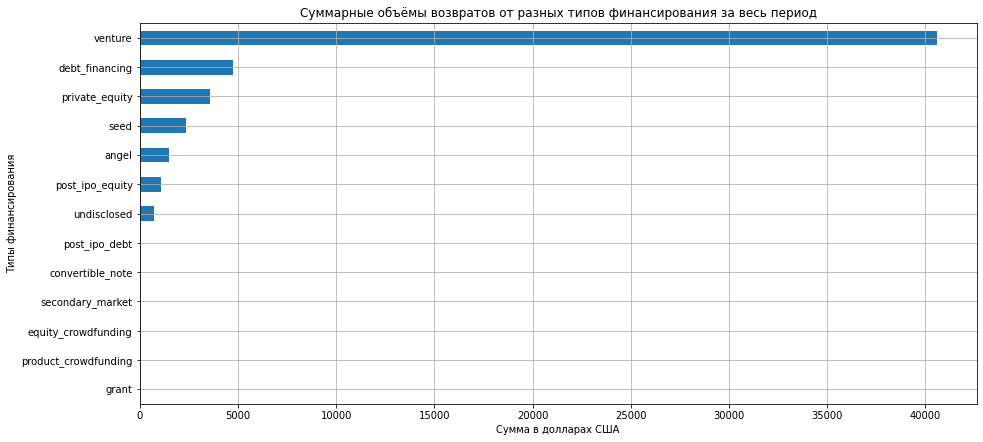

In [44]:
plt.figure(figsize=(15, 7))

cb_returns_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                                    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                                    'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum().sort_values().plot(
               kind='barh', 
               rot=0,
               legend=False, 
               title=f'Суммарные объёмы возвратов от разных типов финансирования за весь период'
)

plt.xlabel('Сумма в долларах США')
plt.ylabel('Типы финансирования')  

plt.grid() 

plt.show() 

Промежуточный вывод: во всех трёх графиках лидирующие позиции занимает тип финансирования `venture`. Это самый популярный, ликвидный вариант для заказчика, стоит обратить внимание на этот тип финансирования.

## Шаг 4. Анализ динамики
[↑ К оглавлению](#contents)

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

In [45]:
cb_investments_df['avg_round_size'] = cb_investments_df['funding_total_usd'] / cb_investments_df['funding_rounds']

print(cb_investments_df[['name', 'avg_round_size']].head(5))

                              name  avg_round_size
1      University of New Brunswick      2000000.00
2                           DuPont      9000000.00
3           University of Michigan      2566666.75
4  Case Western Reserve University       540000.00
7                  Duke University      8700000.00


In [46]:
cb_investments_df['year'] = pd.to_datetime(cb_investments_df['mid_funding_at']).dt.year

print(cb_investments_df[['name', 'year', 'avg_round_size']].head(5))

                              name  year  avg_round_size
1      University of New Brunswick  2014      2000000.00
2                           DuPont  2009      9000000.00
3           University of Michigan  2013      2566666.75
4  Case Western Reserve University  2014       540000.00
7                  Duke University  2014      8700000.00


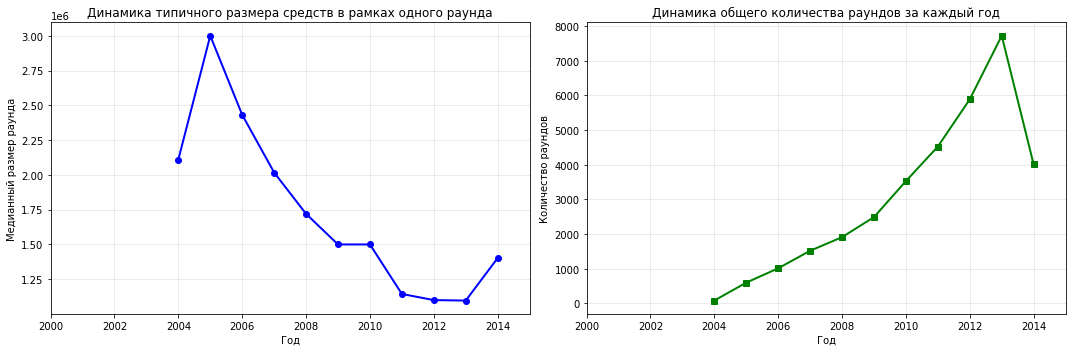

In [47]:
yearly_round_size = cb_investments_df.groupby('year')['avg_round_size'].median().sort_index()

yearly_rounds_count = cb_investments_df.groupby('year')['funding_rounds'].sum().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

yearly_round_size.plot(ax=ax1, marker='o', linewidth=2, color='blue')
ax1.set_title('Динамика типичного размера средств в рамках одного раунда', fontsize=12)
ax1.set_xlabel('Год')
ax1.set_ylabel('Медианный размер раунда')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2000, 2015)

yearly_rounds_count.plot(ax=ax2, marker='s', linewidth=2, color='green')
ax2.set_title('Динамика общего количества раундов за каждый год', fontsize=12)
ax2.set_xlabel('Год')
ax2.set_ylabel('Количество раундов')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2000, 2015)

plt.tight_layout()
plt.show()

В 2005 году типичный размер средств, собранных в рамках одного раунда, был максимальным. Медианный размер раунда в 2005 году составил $3,000,000, что является максимальным значением за весь рассматриваемый период.

В 2014 году наблюдалась разнонаправленная тенденция: Количество раундов снизилось на 48,1% (с 7,722 в 2013 году до 4,007 в 2014 году). Это говорит о сокращении инвестиционной активности и уменьшении числа финансируемых проектов.Размер раундов вырос на 27,9% (с 1,096,733 до 1,402,500 долларов США). Наблюдается переход к более крупным инвестиционным раундам при снижении общего числа раундов.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберём из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматриваем только массовые сегменты, а средние и нишевые исключите.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [48]:
pivot_table = pd.pivot_table(
    cb_investments_df,
    index='year',                     
    columns='market_groups',            
    values='funding_total_usd',          
    aggfunc='sum',                       
    fill_value=0                          
)

print(pivot_table.head(5))

market_groups   Advertising    Analytics     Apps    Automotive    Big Data   \
year                                                                           
2004                 6000000      3000000        0             0           0   
2005                27500000     26157500        0             0           0   
2006                96966936     47940000  1310600       2060000           0   
2007               156944096      9058000        0       9400000     7780000   
2008               122511456     30211200  4050000      33275580     2302515   

market_groups   Biotechnology    Clean Technology    Cloud Computing   \
year                                                                    
2004                   5819644                   0                  0   
2005                 160850992             7420000                  0   
2006                 157697808            10570000            9416354   
2007                 258715056            96930992            4854343   
2

In [49]:
data_2013 = pivot_table.loc[2013]
data_2014 = pivot_table.loc[2014]

growing_segments = data_2014[data_2014 > data_2013].index.tolist()
print(growing_segments)

mass_growing = [s for s in growing_segments if s not in ['mid', 'niche']]
print(mass_growing)

[' Apps ', ' Cloud Computing ', ' Entertainment ', ' Internet ', ' Medical ', ' Networking ', ' Photography ', ' Real Estate ', ' Software', ' Sports ', ' Startups ', 'niche']
[' Apps ', ' Cloud Computing ', ' Entertainment ', ' Internet ', ' Medical ', ' Networking ', ' Photography ', ' Real Estate ', ' Software', ' Sports ', ' Startups ']


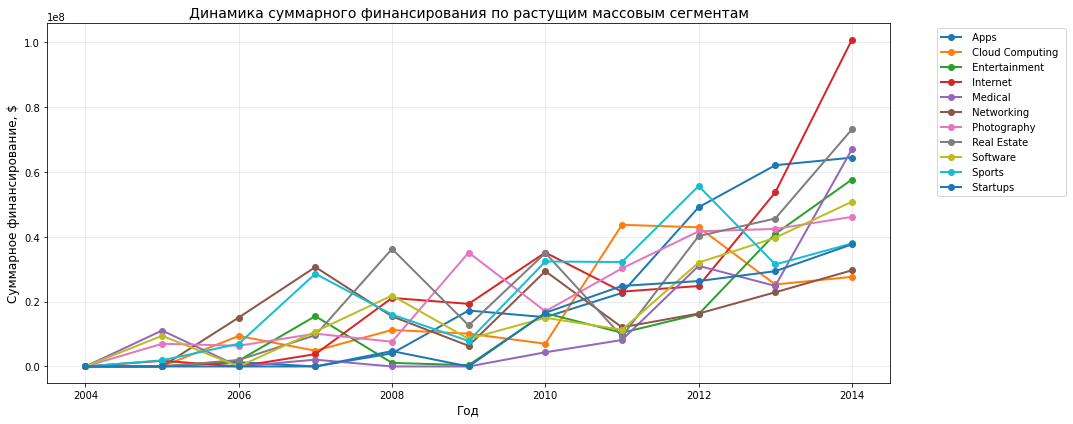

In [50]:
pivot_growth = pivot_table[mass_growing]

fig, ax = plt.subplots(figsize=(15, 6))

pivot_growth.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Динамика суммарного финансирования по растущим массовым сегментам', fontsize=14)
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Суммарное финансирование, $', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

На графике «Динамика суммарного финансирования по растущим массовым сегментам» видно, что наиболее быстрый и уверенный рост в период с 2004 по 2014 годы демонстрируют следующие сегменты:
- Internet;
- Real Estate;
- Photography;
- Entertainment;
- Startups.

Для заказчика:
Наиболее быстрый и уверенный рост показывают вышепредставленные технологические сегменты.
Именно они должны рассматриваться как приоритетные для инвестиций в 2015 году, так как сочетают в себе как высокие объёмы финансирования, так и устойчивую положительную динамику.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [51]:
investment_by_year = pd.DataFrame()

types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
         'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
         'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

for t in types:
    yearly_sum = cb_investments_df.groupby('year')[t].sum()
    investment_by_year[t] = yearly_sum

investment_by_year = investment_by_year / 1000000
investment_by_year

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2004,14.809565,152.835024,0.000000,10.847144,0.000000,6.000000,4.980741,10.273600,0.000000,0.000000,0.000000,0.000000,0.000000
2005,35.684096,1894.762624,0.000000,2.652724,0.000000,8.547671,52.742272,6.266481,0.000000,0.000000,0.000000,0.000000,0.000000
2006,45.296884,2532.760320,0.933057,42.019216,6.365000,40.696256,61.570588,0.647500,3.420000,0.000000,0.000000,0.000000,0.000000
2007,156.907808,3061.482240,0.000000,37.078424,3.532054,66.465364,178.932864,2.930000,18.417414,0.000000,0.000000,0.000000,0.000000
2008,234.099856,3367.834368,0.000000,48.534048,11.054186,87.581728,209.031216,16.254516,0.000000,0.000000,0.000000,0.000000,1.000000
2009,221.323856,3901.619712,2.049671,47.054496,17.260582,309.607808,134.026976,23.735674,46.802084,1.000000,0.000000,0.000000,0.303050
2010,402.846048,4980.396544,0.400000,107.701896,22.350204,362.609280,181.197392,125.332264,67.375672,4.000000,0.000000,0.910000,3.500000
2011,970.730048,4771.893760,1.960343,127.657280,35.217560,425.233216,297.858176,83.985224,133.291216,14.319266,3.100000,0.000000,3.014061
2012,1636.441728,5490.778624,14.693595,170.426480,72.077072,428.509568,346.725952,87.047432,260.723968,20.517152,0.000000,0.000000,9.812431


In [52]:
norm_returns = investment_by_year.copy()

types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
         'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
         'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

for t in types:
    norm_returns[t] = cb_returns_df[t] / (investment_by_year[t] + 1e-60)
    norm_returns.loc[norm_returns[t] > 10, t] = pd.NA # Если доля возврата больше в 10 раз - значит аномалия, меняем на пропуски

print(norm_returns.head())

          seed   venture equity_crowdfunding undisclosed convertible_note  \
year                                                                        
2004  0.670513  3.637255                 0.0    3.059791             <NA>   
2005   0.74543  1.387467                 0.0    3.584994             <NA>   
2006  1.364553  1.224032            0.203632    1.112348         0.279654   
2007  0.448735  1.171122                <NA>    1.493321         0.911651   
2008  0.383255  0.806756                <NA>     0.84518         0.154693   

     debt_financing     angel grant private_equity post_ipo_equity  \
year                                                                 
2004       2.258333  1.843099   0.0           <NA>            <NA>   
2005       4.105212  0.588901   0.0           <NA>            <NA>   
2006       2.781828  0.775533   0.0       4.874269            <NA>   
2007        1.89091  0.919395   0.0       4.822067            <NA>   
2008       4.539075  0.491936   0.0     

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

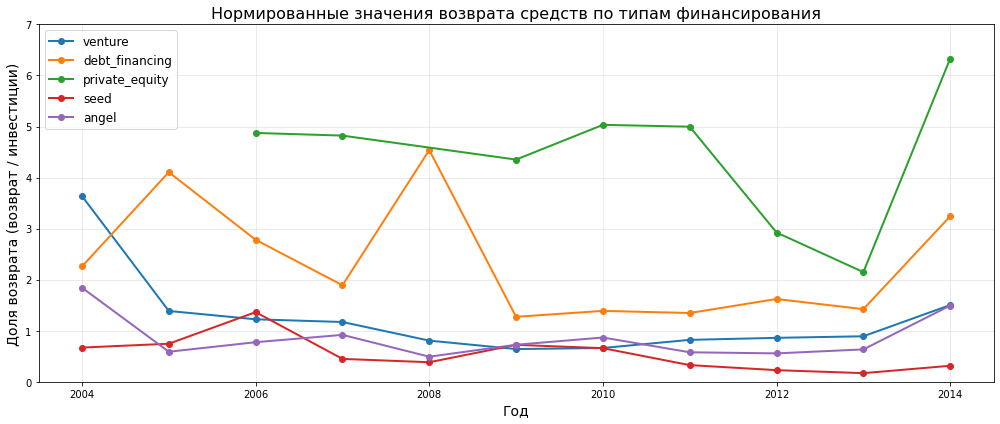

In [53]:
key_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(14, 6))

for t in key_types:
    clean_data = norm_returns[t].dropna()
    if not clean_data.empty:
        plt.plot(clean_data.index, clean_data.values, marker='o', linewidth=2, label=t)

plt.title('Нормированные значения возврата средств по типам финансирования', fontsize=16)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Доля возврата (возврат / инвестиции)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.ylim(0, 7)  

plt.tight_layout()
plt.show()

Венчурные инвестиции (venture) демонстрируют наиболее устойчивый рост показателя. Несмотря на высокие значения в начале периода (что может объясняться эффектом низкой базы), начиная с 2010 года наблюдается стабильная положительная динамика. К 2014 году доля возврата уверенно превышает порог окупаемости (значение >1).

## Шаг 5. Итоговый вывод и рекомендации
[↑ К оглавлению](#contents)

В ходе проекта были выполнены следующие этапы анализа:
- Знакомство с данными и предобработка. Загрузили данные, привели названия столбцов к единому стилю (snake_case), очистили `funding_total_usd` от разделителей разрядов, преобразовали типы данных (даты, числовые), удалили дубликаты и строки без информации о финансировании, восстановили пропуски в mid_funding_at. Потери данных составили 24.66%, что допустимо для дальнейшего анализа.
- Инжиниринг признаков. Разделили компании на 3 группы по срокам финансирования; классифицировали рыночные сегменты на массовые (> 120 компаний), средние (35–120) и нишевые (< 35); создали столбец market_groups с заменой средних и нишевых сегментов на заглушки.
- Работа с выбросами и анализ. Визуально оценили типичный размер финансирования (350K–10M долларов США), применили метод IQR для выявления аномалий, удалили компании с аномальным финансированием, ограничили период годами с активностью >= 50 раундов. Проанализировали типы финансирования по объёму и популярности: лидер по всем показателям — venture.
- Анализ динамики. Рассчитали динамику размера раундов и количества инвестиций по годам; выявили растущие массовые сегменты (`Internet`, `Real Estate`, `Photography`, `Entertainment`, `Startups`); рассчитали нормированные доли возврата для всех типов финансирования и построили график для 5 ключевых типов.

В какую отрасль инвестировать?
На основе анализа динамики финансирования и структуры рынка, рекомендуем сфокусироваться на следующих массовых сегментах, показавших наиболее уверенный рост в 2014 году:
- `Internet`. Стабильный рост на протяжении всего периода;
- `Real Estate`. Активный рост с 2010 года, пик в 2014;
- `Photography`. Уверенная положительная динамика;
- `Entertainment`. Высокие объёмы и устойчивый рост;
- `Startups`. Категория, аккумулирующая молодые быстрорастущие компании.

Анализ нормированных возвратов однозначно указывает, что наиболее уместным типом финансирования при этом будут венчурные инвестиции `venture` как наиболее сбалансированный инструмент.